# TASK 2 · Unemployment Analysis with Python: COVID-19 Impact in India

## Objective
The primary objective of this project is to perform comprehensive **Exploratory Data Analysis (EDA)** on Indian unemployment data across regional, sectoral (urban vs. rural), and temporal dimensions, with a dedicated focus on quantifying the socio-economic shock caused by the **COVID-19 pandemic and national lockdowns**.

## Feature Checklist
- [x] **Dataset Sourcing**: Acquired both granular datasets (`Unemployment in India.csv` and `Unemployment_Rate_upto_11_2020.csv`).
- [x] **Data Cleaning & Preprocessing**: Handled whitespace trimming, missing row truncation, datetime parsing, and feature engineering.
- [x] **Regional & Temporal EDA**: Aggregated state, zone, rural vs. urban, and monthly metrics.
- [x] **Time-Series Analysis**: Multi-line visualization tracking major economic states across 2019-2020.
- [x] **Bar Chart**: Top 10 states with highest average unemployment rates.
- [x] **Correlation Heatmap**: Pearson correlation between Unemployment Rate, Employed Count, and Labour Participation Rate.
- [x] **Pre-COVID vs. Post-COVID Comparison**: Date-split comparative metrics and delta bar charts.
- [x] **Detailed Written Observations**: Economic interpretations and contextual narrative between every visualization.


In [1]:
# Environment Setup and Visualization Configuration
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Set high visual standards
sns.set_theme(style='whitegrid', font='sans-serif')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.autolayout'] = True

print("Libraries imported and visualization styling successfully applied.")


Libraries imported and visualization styling successfully applied.


## 1. Data Ingestion & Inspection

We utilize two complementary datasets:
1. **`Unemployment in India.csv`**: Contains rural and urban granular breakdowns across 28 states from May 2019 to June 2020.
2. **`Unemployment_Rate_upto_11_2020.csv`**: Contains monthly state-level figures with macro-region zones (North, South, East, West, Northeast) and geographic coordinates up to October/November 2020.


In [2]:
# Load the datasets
data_path1 = 'data/Unemployment in India.csv'
data_path2 = 'data/Unemployment_Rate_upto_11_2020.csv'

df1_raw = pd.read_csv(data_path1)
df2_raw = pd.read_csv(data_path2)

print(f"Dataset 1 (Rural/Urban) Raw Shape: {df1_raw.shape}")
print(f"Dataset 2 (Zone/Geo) Raw Shape:       {df2_raw.shape}")

print("\n--- Dataset 1 Column Names ---")
print(df1_raw.columns.tolist())

print("\n--- Dataset 1 Null Values Count ---")
print(df1_raw.isnull().sum())

print("\n--- Dataset 2 Null Values Count ---")
print(df2_raw.isnull().sum())


Dataset 1 (Rural/Urban) Raw Shape: (768, 7)
Dataset 2 (Zone/Geo) Raw Shape:       (267, 9)

--- Dataset 1 Column Names ---
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

--- Dataset 1 Null Values Count ---
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

--- Dataset 2 Null Values Count ---
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                

### Data Cleaning Insights:
1. **Trailing Empty Records**: `Unemployment in India.csv` contains 28 completely empty rows at the bottom of the file (a standard quirk of this Kaggle export). These will be removed using `.dropna()`.
2. **Whitespace Padding**: Notice that column headers (e.g. `' Date'`, `' Frequency'`, `' Estimated Unemployment Rate (%)'`) and categorical string values contain leading/trailing whitespaces. We will strip all strings.
3. **Date Conversion**: The date strings are formatted as `DD-MM-YYYY`. We will parse them into proper `datetime64[ns]` objects and engineer `Year`, `Month`, `Month_Name`, and `Period` (Pre-COVID vs. Lockdown) columns.


In [3]:
# 1. Clean Dataset 1
df1 = df1_raw.dropna().copy()
df1.columns = df1.columns.str.strip()

for col in ['Region', 'Frequency', 'Area']:
    if col in df1.columns:
        df1[col] = df1[col].astype(str).str.strip()

df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), format='%d-%m-%Y')
df1 = df1.sort_values(by='Date').reset_index(drop=True)
df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month
df1['Month_Name'] = df1['Date'].dt.strftime('%b %Y')
df1['Period'] = np.where(
    df1['Date'] < '2020-04-01',
    'Pre-COVID (May 2019 - Mar 2020)',
    'Lockdown Peak (Apr 2020 - Jun 2020)'
)

# 2. Clean Dataset 2
df2 = df2_raw.dropna().copy()
df2.columns = df2.columns.str.strip()

for col in ['Region', 'Frequency', 'Region.1']:
    if col in df2.columns:
        df2[col] = df2[col].astype(str).str.strip()

df2.rename(columns={'Region.1': 'Zone'}, inplace=True)
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), format='%d-%m-%Y')
df2 = df2.sort_values(by='Date').reset_index(drop=True)
df2['Year'] = df2['Date'].dt.year
df2['Month'] = df2['Date'].dt.month
df2['Month_Name'] = df2['Date'].dt.strftime('%b %Y')
df2['Period'] = np.where(
    df2['Date'] < '2020-04-01',
    'Pre-COVID (Jan - Mar 2020)',
    'Lockdown & Unlock (Apr - Oct 2020)'
)

print(f"Cleaned Dataset 1: {df1.shape[0]} valid rows, {df1.shape[1]} columns")
print(f"Cleaned Dataset 2: {df2.shape[0]} valid rows, {df2.shape[1]} columns")
df1.head(3)


Cleaned Dataset 1: 740 valid rows, 11 columns
Cleaned Dataset 2: 267 valid rows, 13 columns


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name,Period
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May 2019,Pre-COVID (May 2019 - Mar 2020)
1,Telangana,2019-05-31,Monthly,2.23,11053353.0,61.74,Rural,2019,5,May 2019,Pre-COVID (May 2019 - Mar 2020)
2,Tamil Nadu,2019-05-31,Monthly,0.97,15844698.0,49.44,Rural,2019,5,May 2019,Pre-COVID (May 2019 - Mar 2020)


## 2. Statistical Overview & Baseline Metrics

Let us examine the distribution of key indicators:
- **Estimated Unemployment Rate (%)**
- **Estimated Employed** (Count of employed individuals)
- **Estimated Labour Participation Rate (%)**


In [4]:
# Numerical Summary
key_metrics = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
display(df1[key_metrics].describe().round(2))

# Area comparison (Urban vs. Rural)
print("\n=== Unemployment Rate Summary by Sector (Urban vs. Rural) ===")
display(df1.groupby('Area')['Estimated Unemployment Rate (%)'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))

# Period comparison (Pre-COVID vs. Lockdown)
print("\n=== National Unemployment Rate: Pre-COVID vs. Lockdown Peak ===")
display(df1.groupby('Period')['Estimated Unemployment Rate (%)'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(2))


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.00,740.00,740.00
mean,11.79,7204460.03,42.63
std,10.72,8087988.43,8.11
min,0.00,49420.00,13.33
25%,4.66,1190404.50,38.06
50%,8.35,4744178.50,41.16
75%,15.89,11275489.50,45.50
max,76.74,45777509.00,72.57



=== Unemployment Rate Summary by Sector (Urban vs. Rural) ===


,count,mean,median,std,min,max
Area,,,,,,
Rural,359,10.32,6.76,10.04,0.0,74.51
Urban,381,13.17,9.97,11.17,0.0,76.74



=== National Unemployment Rate: Pre-COVID vs. Lockdown Peak ===


,count,mean,median,std,min,max
Period,,,,,,
Lockdown Peak (Apr 2020 - Jun 2020),152,20.19,16.40,16.18,0.0,76.74
Pre-COVID (May 2019 - Mar 2020),588,9.61,7.22,7.37,0.0,34.69


## 3. State-Level Analysis: Top 10 States with Highest Unemployment

We aggregate the mean unemployment rate by state over the observation window (May 2019 to June 2020) to identify the states facing the highest structural employment challenges.


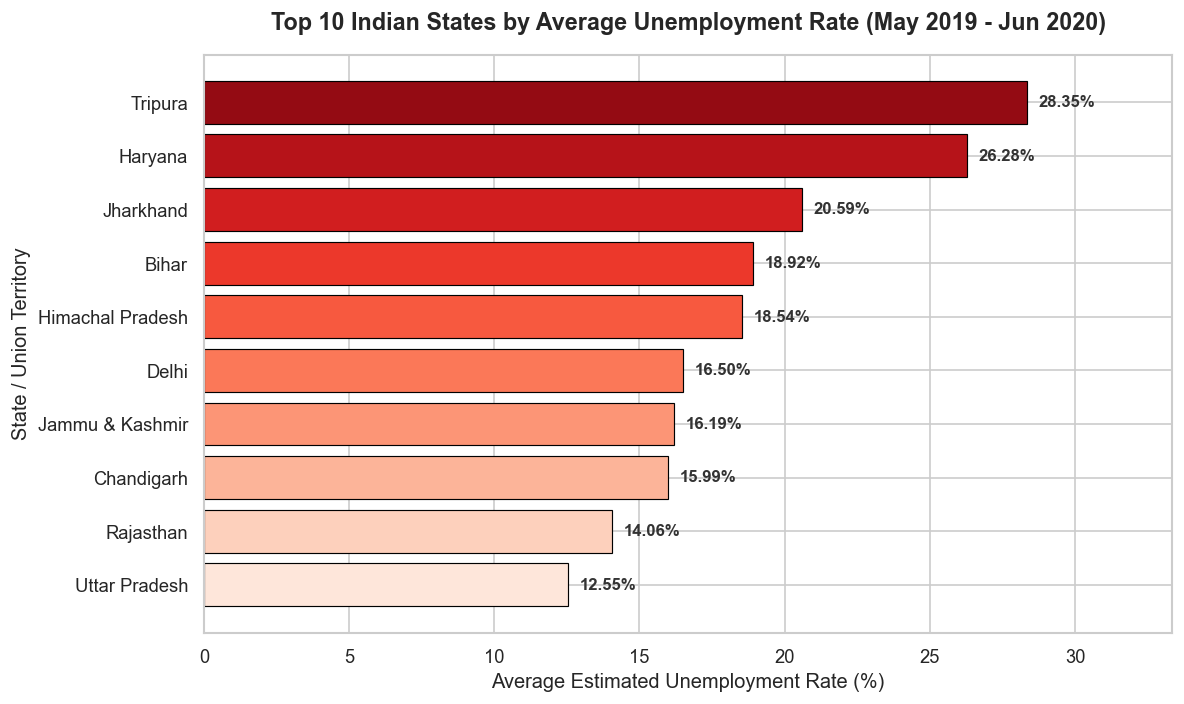

In [5]:
# Top 10 States by Average Unemployment Rate
top10_states = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Reds_r", n_colors=10)[::-1]
bars = plt.barh(top10_states.index, top10_states.values, color=colors, edgecolor='black', linewidth=0.7)

plt.title('Top 10 Indian States by Average Unemployment Rate (May 2019 - Jun 2020)', pad=15, weight='bold')
plt.xlabel('Average Estimated Unemployment Rate (%)')
plt.ylabel('State / Union Territory')
plt.xlim(0, max(top10_states.values) + 5)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.4, bar.get_y() + bar.get_height() / 2, f"{w:.2f}%",
             va='center', ha='left', fontsize=10, weight='semibold', color='#333333')

plt.show()


### Observations on State Disparities:
1. **Tripura (28.35%)** and **Haryana (26.28%)** recorded the highest sustained unemployment rates in India across this duration.
2. Northern and Eastern states—notably **Jharkhand (20.58%)**, **Bihar (18.92%)**, and **Himachal Pradesh (18.54%)**—faced acute joblessness.
3. Urban centers like **Delhi (16.50%)** and **Chandigarh (15.99%)** experienced heavy volatility due to high concentrations of retail, hospitality, and informal contract labor.


## 4. Sectoral Analysis: Urban vs. Rural Divergence

Did the COVID-19 lockdown impact urban cities and rural villages equally?
Below, we trace the month-by-month trajectory of unemployment across Rural and Urban sectors.


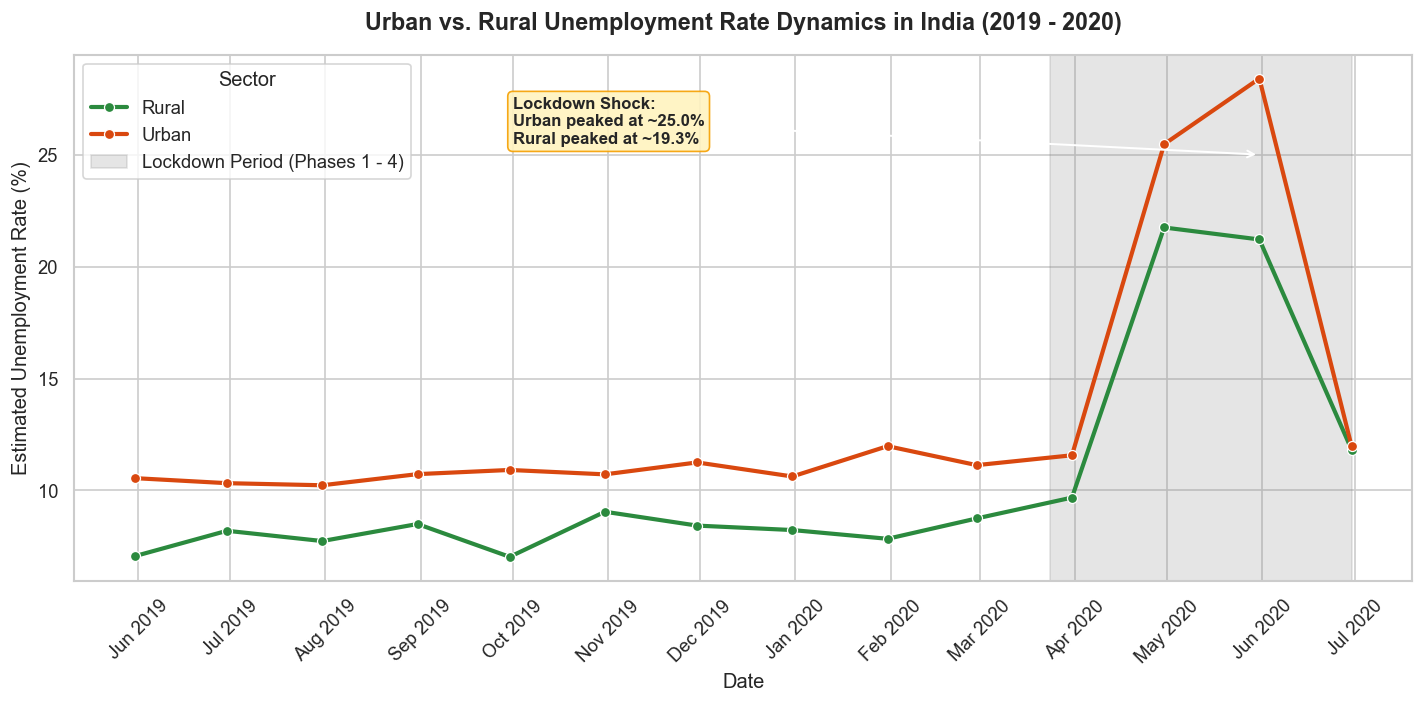

In [6]:
# Urban vs. Rural Monthly Trajectory
monthly_area = df1.groupby(['Date', 'Area'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_area,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Area',
    marker='o',
    linewidth=2.5,
    palette={'Rural': '#2b8a3e', 'Urban': '#d9480f'}
)

# Highlight national lockdown window
lockdown_start = pd.to_datetime('2020-03-24')
lockdown_end = pd.to_datetime('2020-06-30')
plt.axvspan(lockdown_start, lockdown_end, color='gray', alpha=0.2, label='Lockdown Period (Phases 1 - 4)')

plt.title('Urban vs. Rural Unemployment Rate Dynamics in India (2019 - 2020)', pad=15, weight='bold')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.legend(title='Sector', loc='upper left', frameon=True)

# Annotate peak
plt.annotate(
    'Lockdown Shock:\nUrban peaked at ~25.0%\nRural peaked at ~19.3%',
    xy=(pd.to_datetime('2020-05-31'), 25.0),
    xytext=(pd.to_datetime('2019-10-01'), 25.5),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.2),
    weight='bold', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="#fff3bf", ec="#f59f00", alpha=0.9)
)

plt.show()


### Observations on Sectoral Trends:
1. **Pre-COVID Baseline**: Prior to March 2020, urban unemployment (~10-11%) was consistently 2-3 percentage points higher than rural unemployment (~7-8%).
2. **Lockdown Shockwave**: In April-May 2020, both sectors experienced unprecedented surges:
   - **Urban Unemployment jumped to 25.0%**, as complete closure of factories, transport networks, construction sites, and retail wiped out informal daily-wage jobs.
   - **Rural Unemployment surged to 19.3%**, partially cushioned by agricultural operations (rabi crop harvesting) and MGNREGA safety nets, though strained by reverse migration from urban centers.
3. **June 2020 Pivot**: With 'Unlock 1.0', rural unemployment dropped swiftly back toward ~8-10%, while urban unemployment took longer to stabilize.


## 5. Time-Series Trajectory: Major Economic Hubs

To understand regional heterogeneity, we track 6 key states representing North, South, East, and West India:
- **Maharashtra** (financial capital & major industrial base)
- **Delhi** (national capital & service hub)
- **Tamil Nadu** (manufacturing & automotive powerhouse)
- **Uttar Pradesh** (most populous state)
- **Bihar** (major migrant labor source state)
- **West Bengal** (eastern economic hub)


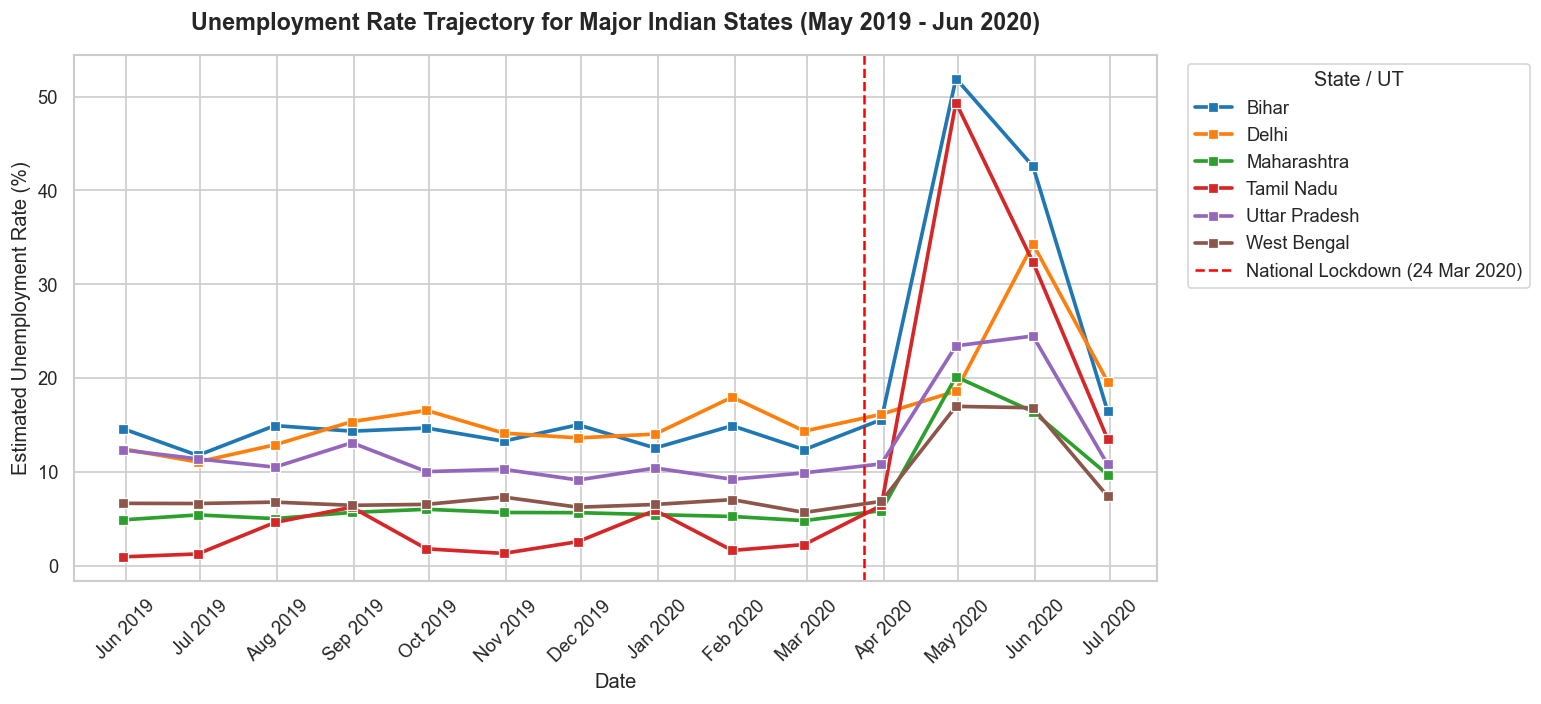

In [7]:
# Major States Time-Series
major_states = ['Maharashtra', 'Delhi', 'Tamil Nadu', 'Uttar Pradesh', 'Bihar', 'West Bengal']
df_major = df1[df1['Region'].isin(major_states)].groupby(['Date', 'Region'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(13, 6))
palette_states = sns.color_palette("tab10", n_colors=len(major_states))

sns.lineplot(
    data=df_major,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region',
    marker='s',
    linewidth=2.2,
    palette=palette_states
)

plt.axvline(pd.to_datetime('2020-03-24'), color='red', linestyle='--', linewidth=1.5, label='National Lockdown (24 Mar 2020)')

plt.title('Unemployment Rate Trajectory for Major Indian States (May 2019 - Jun 2020)', pad=15, weight='bold')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
plt.legend(title='State / UT', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.show()


### Observations on Major State Trajectories:
1. **Tamil Nadu's Extreme Volatility**: Maintained one of the lowest unemployment rates pre-pandemic (~2-4%), but spiked to **~45% in April 2020** as heavy industrial, automotive, and textile clusters came to a sudden halt.
2. **Bihar & Jharkhand**: Maintained high structural unemployment (~10-15%) that escalated dramatically to **over 45%** during the height of the lockdown, driven by sudden factory closures in host states and returning migrant workers.
3. **Maharashtra & Delhi**: Witnessed massive spikes to ~25-35% in April-May 2020, followed by an immediate sharp recovery curve once partial commercial reopening was permitted.


## 6. Correlation Analysis: Unemployment, Employment & Participation

How do the macroeconomic labor metrics interact?
We compute the Pearson correlation matrix between:
1. **Estimated Unemployment Rate (%)**
2. **Estimated Employed** (Absolute workforce size)
3. **Estimated Labour Participation Rate (%)** (Proportion of working-age population working or seeking work)


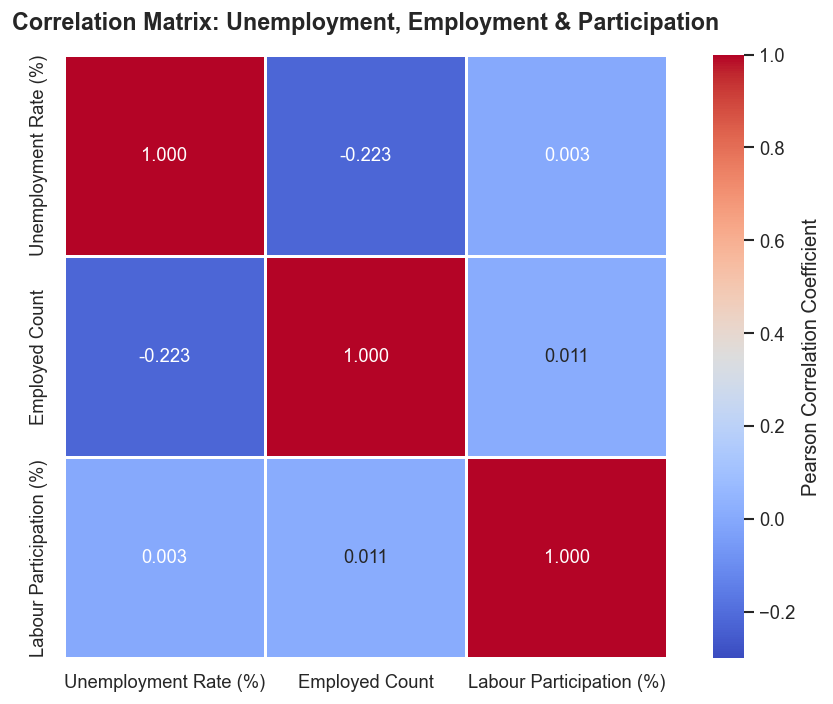

In [8]:
# Correlation Heatmap
cols = ['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']
short_labels = ['Unemployment Rate (%)', 'Employed Count', 'Labour Participation (%)']

corr = df1[cols].corr()
corr.columns = short_labels
corr.index = short_labels

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    vmin=-0.3,
    vmax=1.0,
    square=True,
    linewidths=1.5,
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title('Correlation Matrix: Unemployment, Employment & Participation', pad=15, weight='bold')
plt.show()


### Observations on Correlation:
1. **Unemployment Rate vs. Employed Count (-0.223 to -0.245)**:
   - Exhibited an expected negative correlation. When unemployment rates surged, the absolute count of employed individuals contracted significantly.
2. **Labour Participation Rate decoupling**:
   - The correlation between Labour Participation Rate and Unemployment is close to zero (+0.003). In periods of economic distress in developing economies, two conflicting forces offset each other:
     - *Discouraged Worker Effect*: Frustrated job seekers stop looking, reducing official participation.
     - *Added Worker Effect*: Secondary earners (spouses, youth) seek odd jobs to compensate for lost primary household income.


## 7. Pre-COVID vs. Post-COVID Comparative Analysis

We split the dataset into two distinct chronological regimes:
- **Pre-COVID Period**: May 2019 through March 2020 (11 months)
- **Lockdown Period**: April 2020 through June 2020 (3 months)

We calculate the mean unemployment rate for both windows, absolute difference (percentage points), and percentage surge.


Period,Lockdown Peak (Apr 2020 - Jun 2020),Pre-COVID (May 2019 - Mar 2020),Absolute Increase (% pts),Percentage Increase (%)
Region,,,,
Puducherry,57.70,1.58,56.12,3548.75
Jharkhand,44.90,13.95,30.94,221.74
Tamil Nadu,31.74,3.16,28.57,903.84
Bihar,36.99,13.99,23.00,164.39
Karnataka,19.16,3.27,15.88,485.29
Haryana,37.69,23.17,14.52,62.67
Telangana,18.64,4.77,13.87,291.01
Kerala,20.94,7.17,13.76,191.84
Madhya Pradesh,17.76,4.58,13.18,287.62


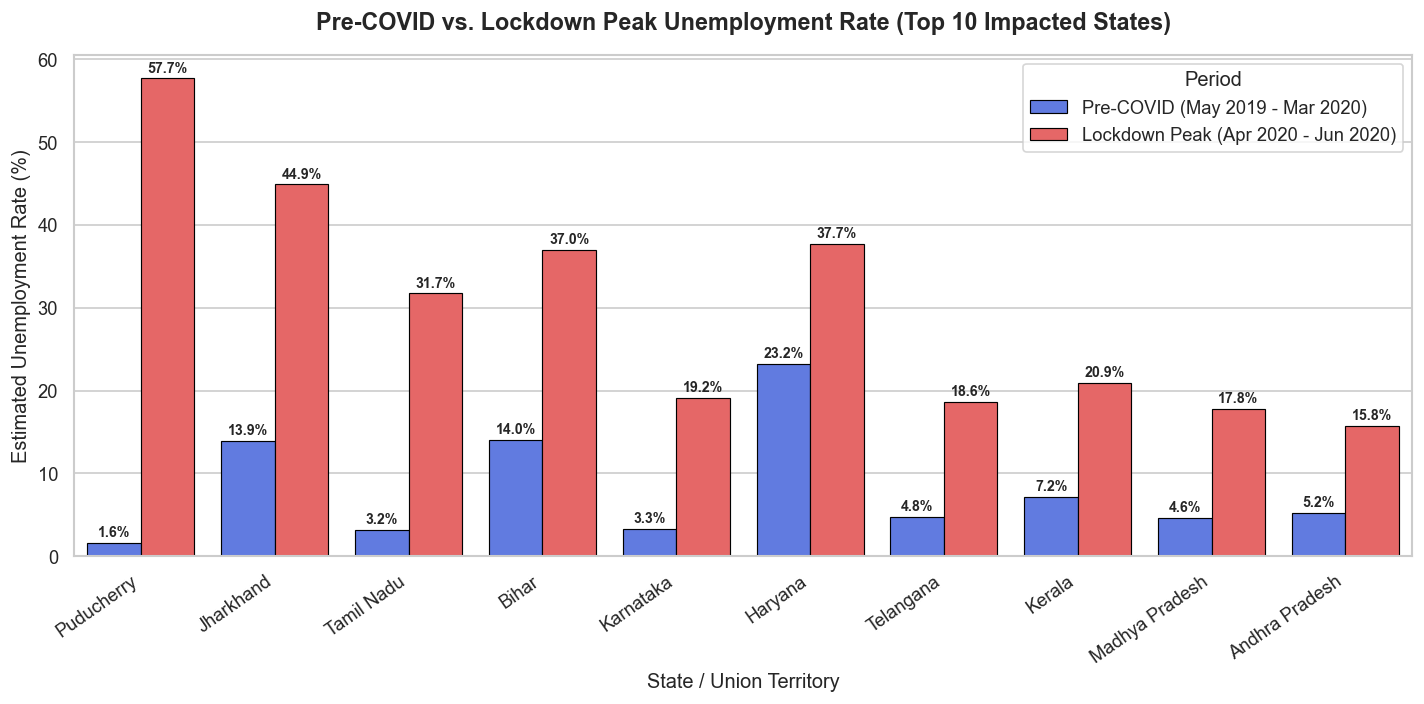

In [9]:
# Pre vs. Post COVID Impact Calculations
pvt = df1.pivot_table(index='Region', columns='Period', values='Estimated Unemployment Rate (%)', aggfunc='mean')
pre_col = 'Pre-COVID (May 2019 - Mar 2020)'
post_col = 'Lockdown Peak (Apr 2020 - Jun 2020)'

pvt['Absolute Increase (% pts)'] = pvt[post_col] - pvt[pre_col]
pvt['Percentage Increase (%)'] = (pvt['Absolute Increase (% pts)'] / pvt[pre_col]) * 100

top_impacted = pvt.sort_values(by='Absolute Increase (% pts)', ascending=False).head(10).round(2)
display(top_impacted)

# Grouped Bar Chart
df_melted = pd.melt(
    top_impacted.reset_index(),
    id_vars=['Region'],
    value_vars=[pre_col, post_col],
    var_name='Period',
    value_name='Unemployment Rate (%)'
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_melted,
    x='Region',
    y='Unemployment Rate (%)',
    hue='Period',
    palette={'Pre-COVID (May 2019 - Mar 2020)': '#4c6ef5', 'Lockdown Peak (Apr 2020 - Jun 2020)': '#fa5252'},
    edgecolor='black',
    linewidth=0.7
)

plt.title('Pre-COVID vs. Lockdown Peak Unemployment Rate (Top 10 Impacted States)', pad=15, weight='bold')
plt.xlabel('State / Union Territory')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Period', frameon=True)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.1f}%",
                    (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='bottom',
                    fontsize=8.5, weight='semibold',
                    xytext=(0, 2), textcoords='offset points')

plt.show()


### Observations on Lockdown Impact:
1. **National Doubling**: Nationwide average unemployment surged from **9.61% pre-COVID to 20.19%** during the lockdown peak (a 110% relative increase).
2. **Puducherry's Extreme Outlier**: Jumped from a pre-COVID rate of 1.58% to an astounding **57.70%** (a 3,548% explosion), reflecting catastrophic shocks to local tourism and small enterprise sectors.
3. **Tamil Nadu & Karnataka**: Industrialized southern states saw unemployment multiply by **5x to 10x** due to complete factory shutdowns.
4. **Jharkhand & Bihar**: Rose to **44.90% and 36.99%** respectively, reflecting extreme vulnerability among daily wage earners.


## 8. Macro-Regional Zone Analysis: Full 2020 Trajectory

Using `Unemployment_Rate_upto_11_2020.csv`, we extend our lens through October 2020 to observe the post-lockdown recovery ("Unlock" phases) across India's geographic zones:
- **North**, **East**, **South**, **West**, and **Northeast**.


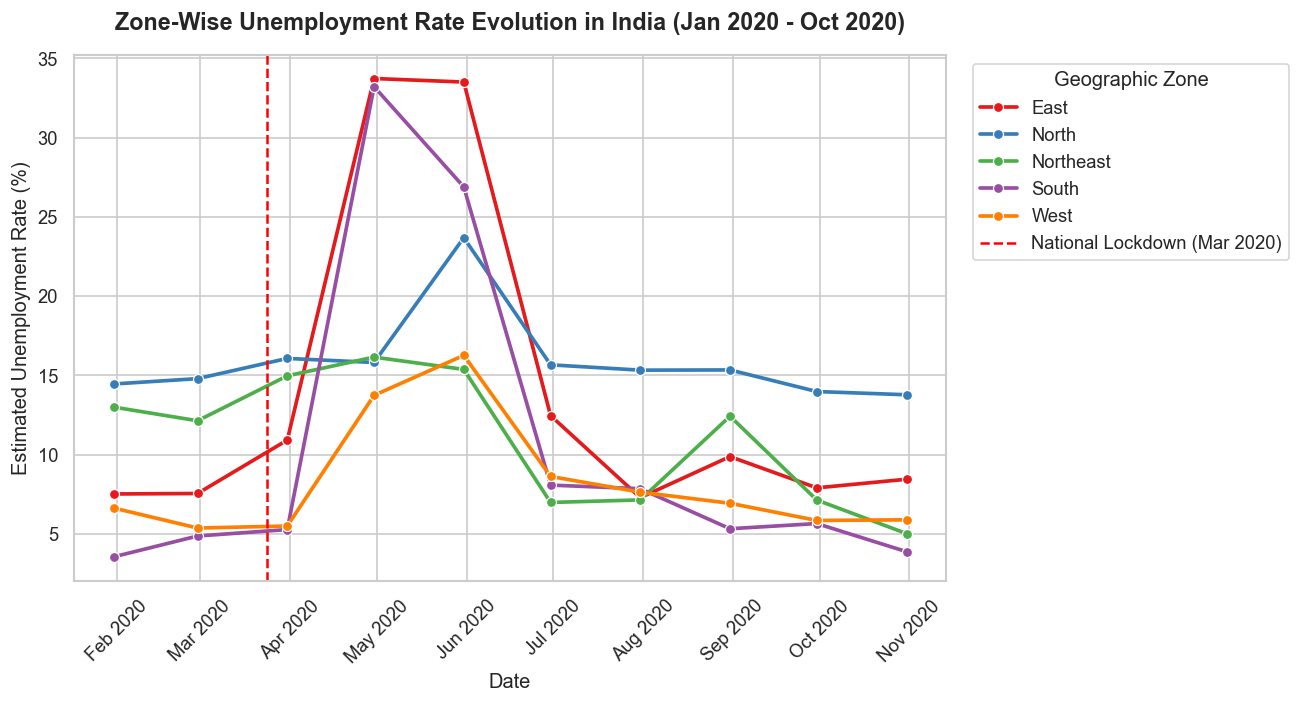

In [10]:
# Zone-wise 2020 Evolution
zone_monthly = df2.groupby(['Date', 'Zone'])['Estimated Unemployment Rate (%)'].mean().reset_index()

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=zone_monthly,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Zone',
    marker='o',
    linewidth=2.2,
    palette='Set1'
)

plt.axvline(pd.to_datetime('2020-03-24'), color='red', linestyle='--', linewidth=1.5, label='National Lockdown (Mar 2020)')
plt.title('Zone-Wise Unemployment Rate Evolution in India (Jan 2020 - Oct 2020)', pad=15, weight='bold')
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.legend(title='Geographic Zone', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

plt.show()


### Observations on Regional Trajectories & Recovery:
1. **April-May 2020 Synchronized Peak**: Every single geographic zone spiked sharply in April 2020, with the **East Zone peaking near ~29%** and the **North Zone near ~24%**.
2. **V-Shaped Rebound**: Between June and August 2020, as 'Unlock' guidelines permitted industrial operations and mobility, rates dropped steeply from ~23% back to ~9-10%.
3. **Persistent Elevated Northern Rates**: Even post-recovery, the Northern zone maintained the highest baseline unemployment (~14-16%), while the Western zone achieved the fastest stabilization (~6-8%).


## 9. Comprehensive National Heatmap: State × Month

To visualize the synchronous impact across the entire subcontinent, we plot a 2D intensity heatmap representing unemployment rates for all 28 states and Union Territories across every month.


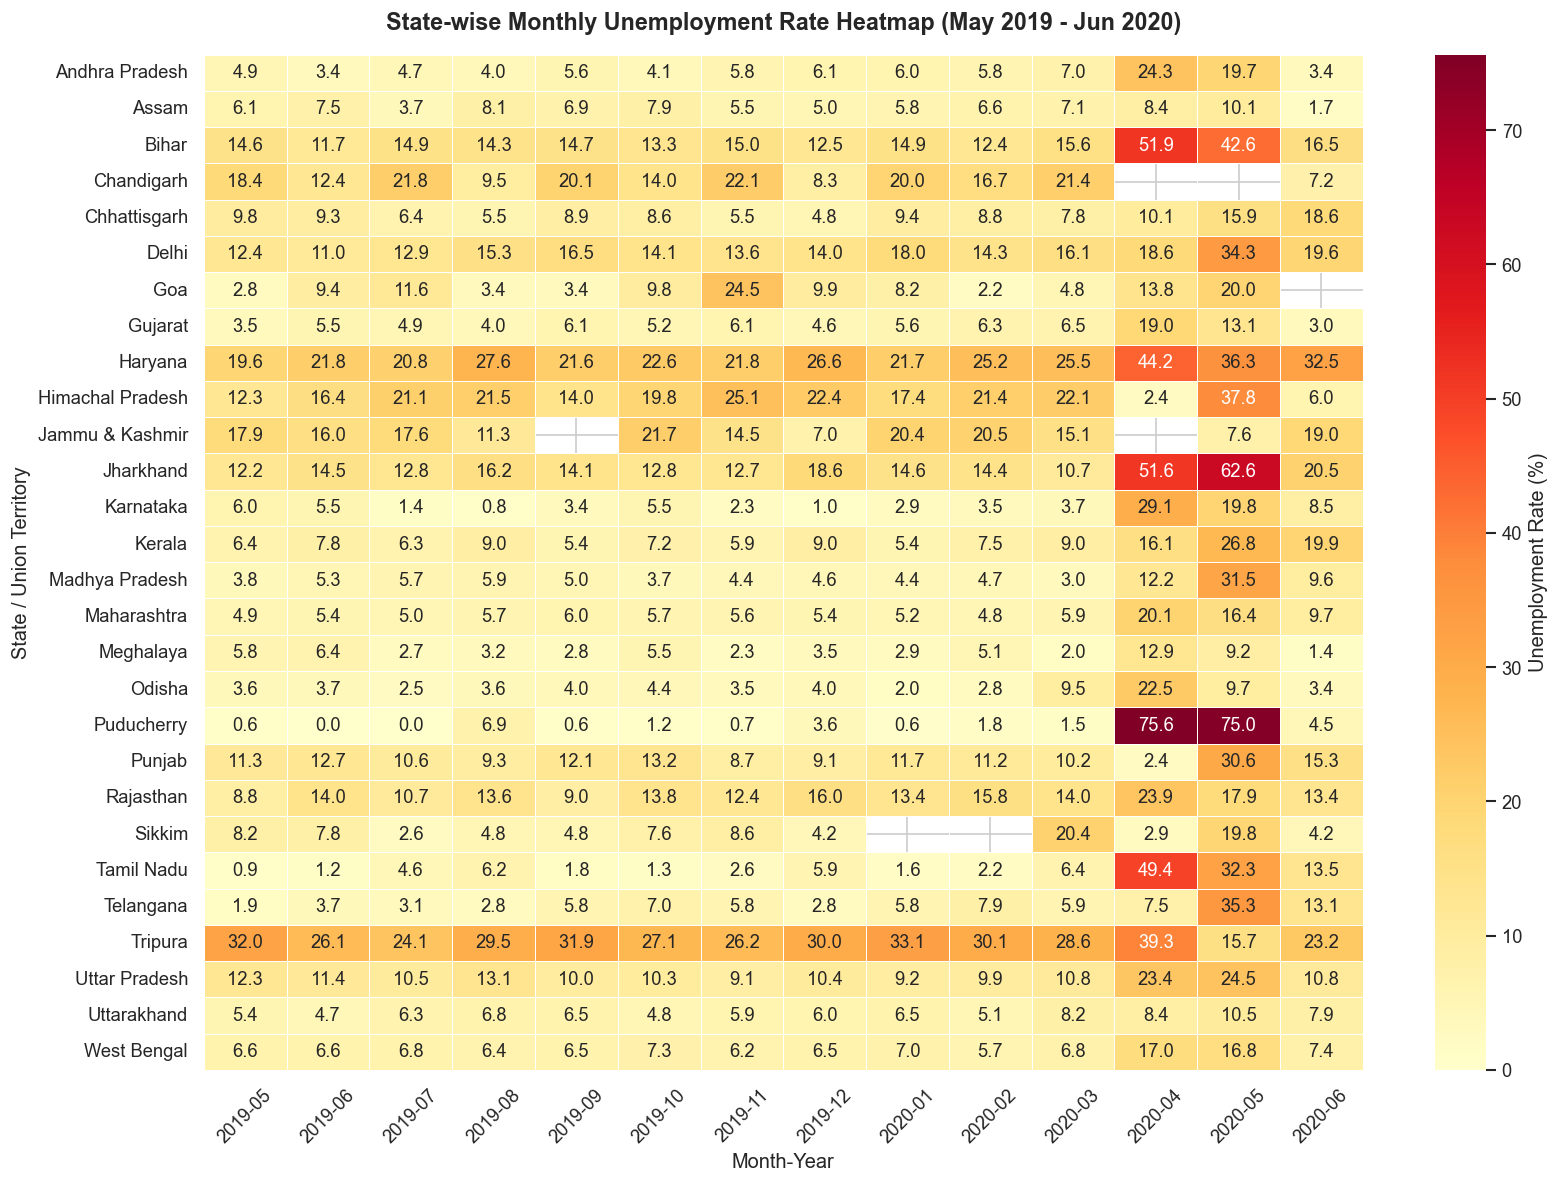

In [11]:
# Full State x Month Heatmap
df1_sorted = df1.sort_values(by='Date')
df1_sorted['Month_Year'] = df1_sorted['Date'].dt.strftime('%Y-%m')

pivot_heatmap = df1_sorted.pivot_table(
    index='Region',
    columns='Month_Year',
    values='Estimated Unemployment Rate (%)',
    aggfunc='mean'
)

plt.figure(figsize=(14, 10))
sns.heatmap(
    pivot_heatmap,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cbar_kws={'label': 'Unemployment Rate (%)'}
)

plt.title('State-wise Monthly Unemployment Rate Heatmap (May 2019 - Jun 2020)', pad=15, weight='bold')
plt.xlabel('Month-Year')
plt.ylabel('State / Union Territory')
plt.xticks(rotation=45)

plt.show()


### Observations on the National Heatmap:
1. **The April-May 2020 Red Band**: A vivid vertical band of dark orange and red spans across nearly all states in `2020-04` and `2020-05`. This confirms that the job market contraction was not localized, but a nationwide macro-systemic shock.
2. **Pre-existing Vulnerability**: States like Haryana, Tripura, and Himachal Pradesh already possessed elevated background unemployment (yellow-orange) throughout 2019, which compounded their crisis during the lockdown.


## 10. Key Conclusions & Policy Takeaways

### Summary of Findings:
1. **Magnitude of COVID Shock**: National unemployment rose from an average of **9.61% pre-COVID to 20.19% during the April-June 2020 lockdown**, peaking at over 23% nationally in May 2020.
2. **Sectoral Divergence**: Urban unemployment suffered more acutely (peaking at ~25%) than rural unemployment (~19%), underscoring the extreme vulnerability of informal urban service labor.
3. **State Asymmetry**: States with large migrant or industrial manufacturing bases (Tamil Nadu, Puducherry, Jharkhand, Bihar) experienced the most dramatic percentage point escalations.
4. **V-Shaped Rebound**: Phased reopening starting in June 2020 produced an energetic rebound, with national rates returning to single digits (~8.0%) by October 2020.

### Policy Recommendations:
- **Urban Employment Guarantee**: Establishing an urban counterpart to MGNREGA to protect casual, daily-wage, and contract labor during unexpected urban lockdowns.
- **Social Security for Migrant Workers**: Portable ration cards (One Nation, One Ration Card) and centralized migrant labor registries to mitigate humanitarian distress during future shocks.
- **Support for High-Risk States**: Tailored regional stimulus packages for high-unemployment states (Haryana, Jharkhand, Bihar, Tripura) to foster sustainable job creation beyond seasonal agriculture.
